Matrix Size    - Naive Time     - NumPy Time 
--------------------------------------------------
   3x3          - 0.002618       - 0.000985      
   6x6          - 0.000060       - 0.000017      
  12x12         - 0.000340       - 0.000015      
  24x24         - 0.002497       - 0.000035      
  48x48         - 0.019805       - 0.000054      
  96x96         - 0.155491       - 0.000277      
 192x192        - 1.228866       - 0.000630      
 384x384        - 10.880475      - 0.003289      


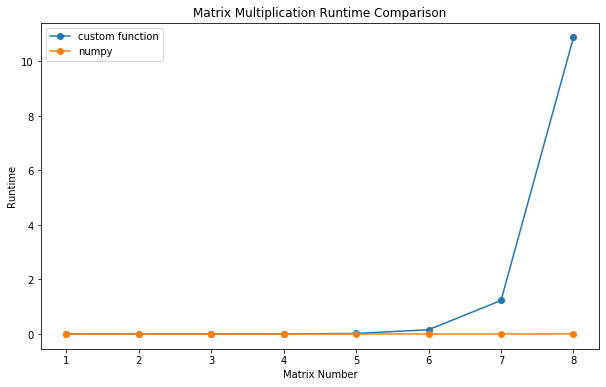

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import time

# matrix multiplication
def naive_matrix_multiplication(A, B):
    n = len(A)
    C = [[0] * n for _ in range(n)]
    
    for i in range(n):
        for j in range(n):
            for k in range(n):
                C[i][j] += A[i][k] * B[k][j]
    
    return C

sizes = [3]
for i in range(7):
    sizes.append(sizes[-1] * 2)

naive_times = []
numpy_times = []
matrix_numbers = list(range(1, 9))

rng = np.random.default_rng()

print("Matrix Size    - Naive Time     - NumPy Time ")
print("-" * 50)

for size in sizes:
    A_np = rng.random((size, size))
    B_np = rng.random((size, size))
    
    A_list = A_np.tolist()
    B_list = B_np.tolist()

    start_time = time.perf_counter()
    naive_result = naive_matrix_multiplication(A_list, B_list)
    end_time = time.perf_counter()
    naive_runtime = end_time - start_time
    naive_times.append(naive_runtime)
    

    start_time = time.perf_counter()
    numpy_result = np.dot(A_np, B_np)
    end_time = time.perf_counter()
    numpy_runtime = end_time - start_time
    numpy_times.append(numpy_runtime)
    
    print(f"{size:>4}x{size:<4}       - {naive_runtime:<14.6f} - {numpy_runtime:<14.6f}")

# plotting
plt.figure(figsize=(10, 6))
plt.plot(matrix_numbers, naive_times, marker='o', label='custom function')
plt.plot(matrix_numbers, numpy_times, marker='o', label='numpy')
plt.title('Matrix Multiplication Runtime Comparison')
plt.xlabel('Matrix Number')
plt.ylabel('Runtime')
plt.xticks(matrix_numbers)
plt.legend()
plt.show()

#Comments
#The native function grows faster than numpys optimized one. The larger the matrix the more the diffrence in runtimes. 